# 02 Preprocessing Single Sample

Loads one subject, filters the EEG, segments fixed 4-second epochs, applies artifact rejection, and prints the final epoch-array shape.

In [1]:
%matplotlib inline
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT / 'src'))

import matplotlib.pyplot as plt
import pandas as pd

from dataset_loader import create_subject_metadata
from preprocessing import PreprocessingConfig, describe_preprocessed_subject, preprocess_subject
from utils import RAW_DATASET_DIR

In [2]:
metadata_df = create_subject_metadata(RAW_DATASET_DIR, verbose=False)
sample_row = metadata_df.iloc[0]
sample_row

subject_id                                              sub-001
label                                                         0
class_name                                                   AD
eeg_file      data\raw\ds004504\sub-001\eeg\sub-001_task-eye...
Name: 0, dtype: object

In [3]:
config = PreprocessingConfig()
preprocessed = preprocess_subject(sample_row['eeg_file'], config=config)
summary = describe_preprocessed_subject(sample_row['subject_id'], sample_row['class_name'], preprocessed)
summary

{'subject_id': 'sub-001',
 'class_name': 'AD',
 'n_channels': 19,
 'sampling_frequency': 500.0,
 'n_epochs': 138,
 'epoch_shape': (138, 19, 2000)}

In [4]:
raw = preprocessed['raw']
filtered = preprocessed['filtered']
epochs = preprocessed['epochs']
epoch_array = preprocessed['epoch_array']
reject_stats = preprocessed['reject_stats']

print(f"Sampling Frequency: {int(raw.info['sfreq'])} Hz")
print(f"Number of Channels: {len(raw.ch_names)}")
print('subject_id:', sample_row['subject_id'])
print('class_name:', sample_row['class_name'])
print('number of epochs:', len(epochs))
print('epoch array shape:', epoch_array.shape)
print('artifact rejection stats:', reject_stats)

Sampling Frequency: 500 Hz
Number of Channels: 19
subject_id: sub-001
class_name: AD
number of epochs: 138
epoch array shape: (138, 19, 2000)
artifact rejection stats: {'total_epochs': 149, 'retained_epochs': 138, 'rejected_epochs': 11, 'rejected_amplitude': 11, 'rejected_high_frequency': 0}


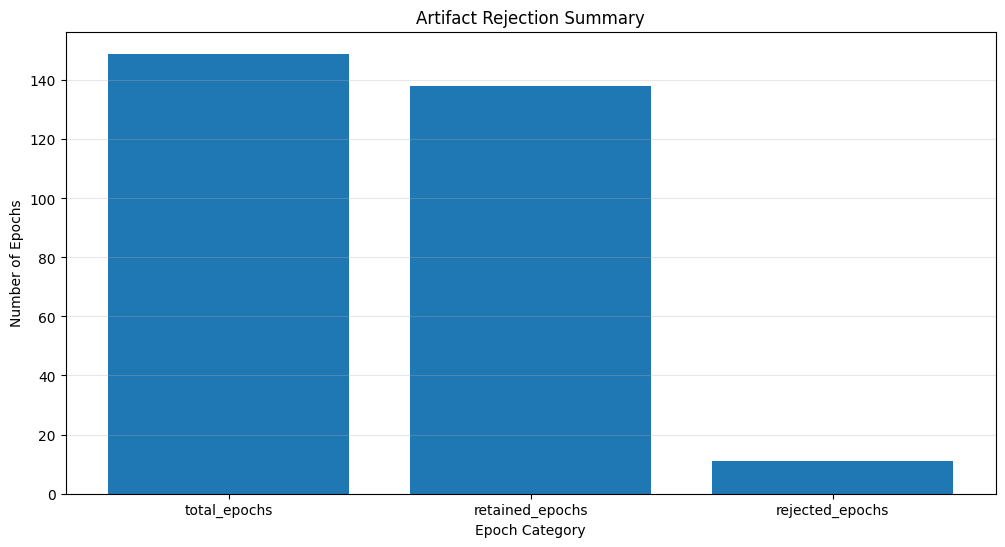

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))
labels = ['total_epochs', 'retained_epochs', 'rejected_epochs']
values = [reject_stats['total_epochs'], reject_stats['retained_epochs'], reject_stats['rejected_epochs']]
ax.bar(labels, values)
ax.set_title('Artifact Rejection Summary')
ax.set_xlabel('Epoch Category')
ax.set_ylabel('Number of Epochs')
ax.grid(True, axis='y', alpha=0.3)
plt.show()

Using matplotlib as 2D backend.


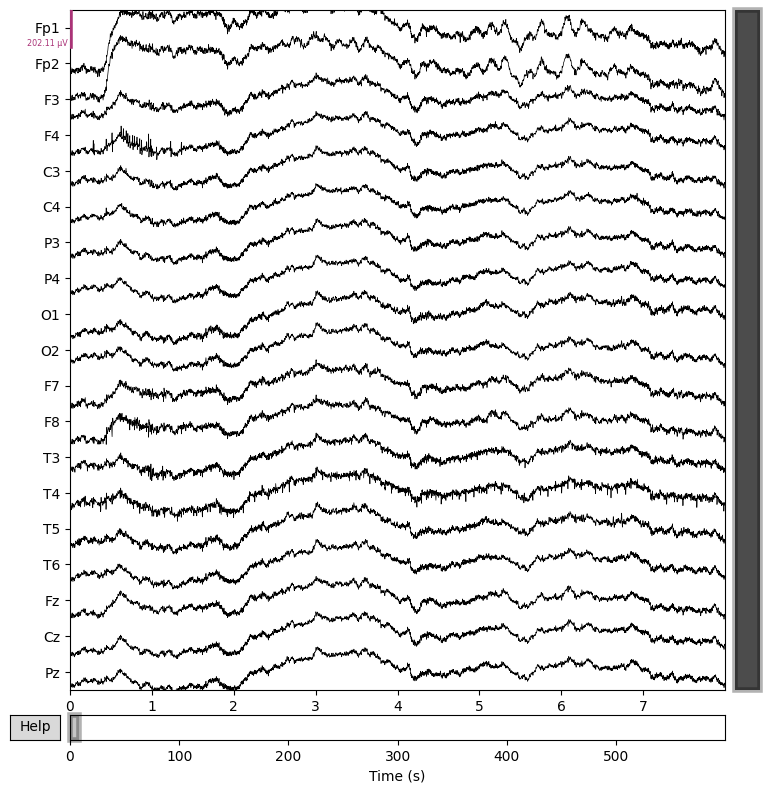

In [6]:
raw.plot(duration=8, n_channels=min(19, len(raw.ch_names)), scalings='auto');

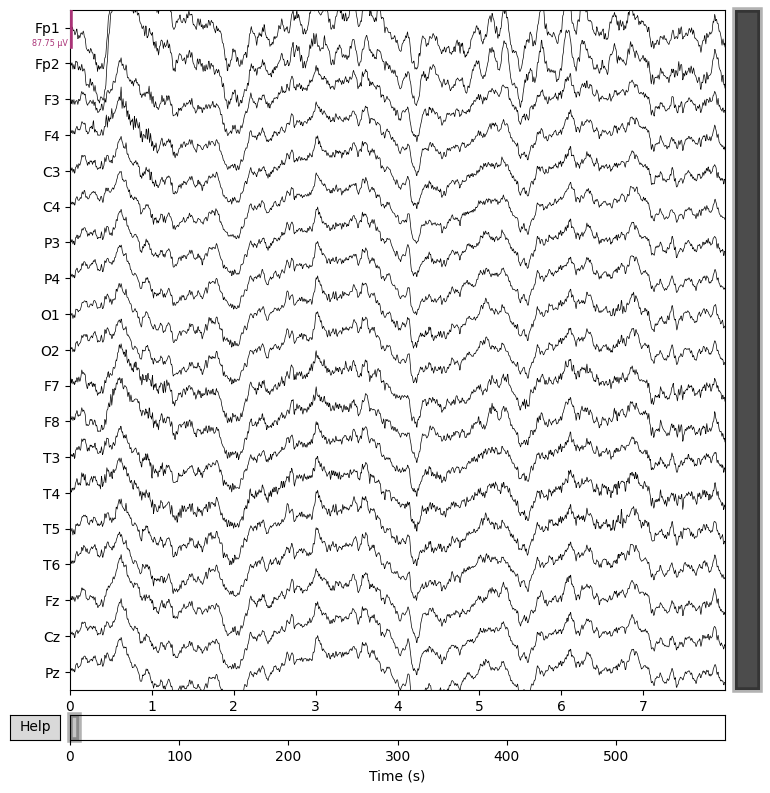

In [7]:
filtered.plot(duration=8, n_channels=min(19, len(filtered.ch_names)), scalings='auto');

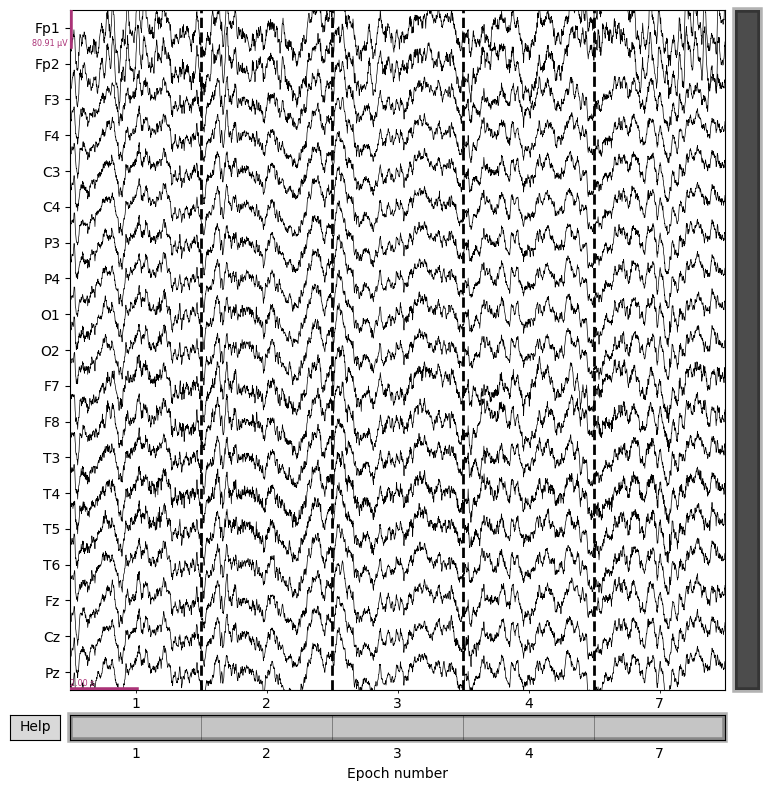

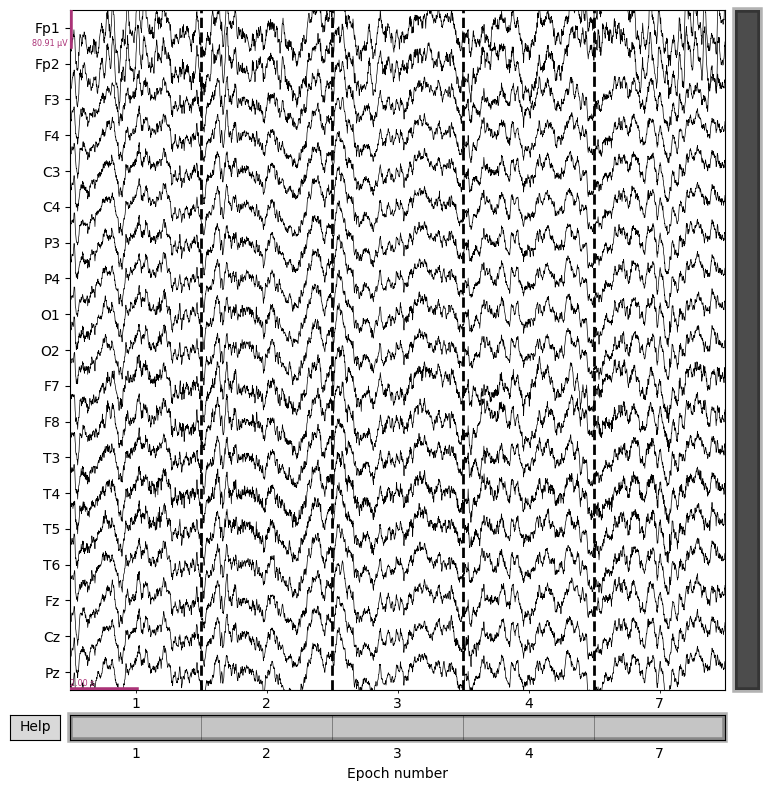

In [8]:
fig = epochs[:5].plot(scalings='auto')
fig